In [1]:
import os
import sys

sys.path.append("/home/koledjoz/Ex2VecExtended")

In [2]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json

In [25]:
df = pd.read_parquet('../../../../sorted_data.parquet')
max_history = 3500
user_count = df['user_id'].max()
item_count = df['track_id'].max()

In [4]:
df['user_id'].value_counts()

user_id
451      3438
5812     3222
596      3202
12251    3135
5212     3115
         ... 
11321    1000
11339    1000
11510    1000
12617    1000
12829    1000
Name: count, Length: 13209, dtype: int64

In [5]:
track_list = [int(x) for x in df['track_id'].unique()]

In [6]:
pos = df.groupby('user_id').cumcount().to_numpy()
users = df['user_id'].to_numpy()
tracks = df['track_id'].to_numpy()
times = df['ts'].to_numpy()

time_history = np.zeros((user_count + 1, max_history), dtype=times.dtype)
item_history = np.zeros((user_count + 1, max_history), dtype=tracks.dtype)

mask = pos < max_history  # safeguard if some users exceed max_history

item_history[users[mask], pos[mask]] = tracks[mask]
time_history[users[mask], pos[mask]] = times[mask]

In [7]:
class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, predict_dict, start_time, end_time, n_steps):
        self.times = []
        self.users = []
        self.items = []

        for u, vals in predict_dict.items():
            for i in vals:
                for t in np.linspace(start_time, end_time, n_steps):
                    self.times.append(int(t))
                    self.users.append(int(u))
                    self.items.append(int(i))
        

    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        return self.times[idx], self.users[idx], self.items[idx]

In [8]:
with open('../../../../split_data/test/test_dict.json', 'r') as f:
    predict_dict = json.load(f)

In [ ]:
predict_dict = {451: track_list}

In [10]:
dataset = DatasetWrapper(predict_dict, 1654041600, 1661990376, 500)

In [11]:
len(dataset)

1513500

In [12]:
batch_size = 2**15
# batch_size = 1

In [13]:
checkpoint_path = "../train_notebooks/extendedDoubleMLP_loss.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

In [14]:
checkpoint['config']

{'n_users': np.int64(13209),
 'n_items': np.int64(3027),
 'latent_d': 64,
 'pretrained_embeddings_path': '/home/koledjoz/Ex2VecExtended/split_data/track_embeddings.parquet',
 'item_mapping': '/home/koledjoz/Ex2VecExtended/configs/models/item_mapping.json',
 'mlp_dist_conf': {'emb_dim': 128,
  'hidden_dims': [256, 128],
  'block_size': 512,
  'activation': torch.nn.modules.activation.ReLU,
  'dropout': 0.1,
  'positive_output': True}}

In [15]:
from src.models.optimized.extendedMLDist import Ex2VecExtendedMLP

device = 'cuda'
config = checkpoint['config']


model = Ex2VecExtendedMLP(config)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.initialize_histories(torch.tensor(item_history).to(device), torch.tensor(time_history).to(device))
model.to(device)

Ex2VecExtendedMLP(
  (user_lamb): Embedding(13210, 1)
  (user_bias): Embedding(13210, 1)
  (item_bias): Embedding(3028, 1)
  (embedding_user): Embedding(13210, 64)
  (embedding_item): Embedding(3028, 64)
  (logistic): Sigmoid()
  (embedding_item_extension): Embedding(3028, 128)
  (metric): OptimizedModule(
    (_orig_mod): FastSymmetricPairwiseMLP(
      (first): Linear(in_features=256, out_features=256, bias=True)
      (hidden): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
      (out): Linear(in_features=128, out_features=1, bias=True)
      (act): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
      (out_act): Softplus(beta=1.0, threshold=20.0)
    )
  )
)

In [17]:
from torch.utils.data import DataLoader

data_list = []

prediction_cols = [f"item_{i + 1}" for i in range(3028)]

with torch.no_grad():
    model.eval()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for step, batch in enumerate(tqdm(dataloader)):
        model_result = model(batch[0].to(device), batch[1].to(device))
        
        user_id = batch[1].cpu().numpy()
        # item_ids = np.array([predict_dict[str(x)] for x in user_id])
        item_ids = batch[2].cpu().numpy()
        ts = batch[0].cpu().numpy()
        
        score = np.take_along_axis(model_result[:, 1:].cpu().numpy(), item_ids[:, None] - 1, axis=1)

        prob = np.take_along_axis(torch.nn.Softmax(dim=1)(model_result[:, 1:]).cpu().numpy(), item_ids[:, None] - 1, axis=1)

        u = user_id.reshape(-1)[:, None]  # -> (B, 1)
        i = item_ids.reshape(-1)[:, None]  # -> (B, 1)
        t = ts.reshape(-1)[:, None]  # -> (B, 1)


        data_list.append(np.concatenate([u, i, t, prob, score], axis=1))


    df = pd.DataFrame(np.concatenate(data_list), columns=['user', 'item', 'ts', 'prob', 'score'])
    df = (
        df.sort_values("ts")  # ensure scores are in time order
        .groupby(["user", "item"])  # group by user & item
        .agg({
            "score": list,
            "prob": list
        })  # collect ordered scores
        .reset_index()
    )


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:51<00:00,  1.11s/it]


In [18]:
prob

array([[7.0805559e-06],
       [6.2749282e-06],
       [6.1031024e-06],
       ...,
       [1.3227306e-07],
       [1.3791016e-07],
       [1.2930478e-07]], shape=(6172, 1), dtype=float32)

In [19]:
output_path = './curves/extended_doublemlploss_predictions_for_curves_full451.csv'

df.to_csv(output_path, index=False)

In [20]:
import matplotlib.pyplot as plt

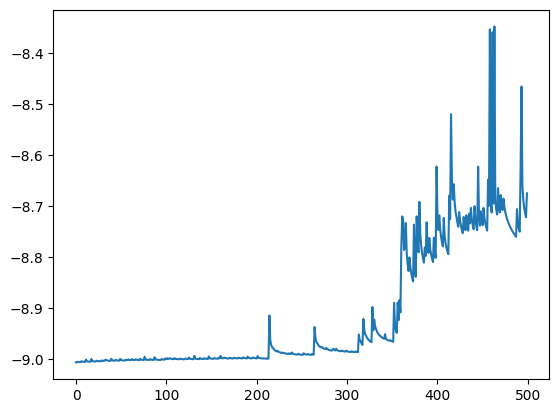

In [21]:
plt.plot(df.iloc[13, 2])

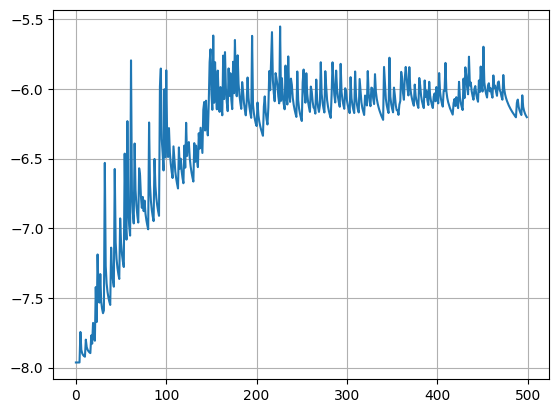

In [22]:
plt.plot(df.iloc[12, 2])
plt.grid()

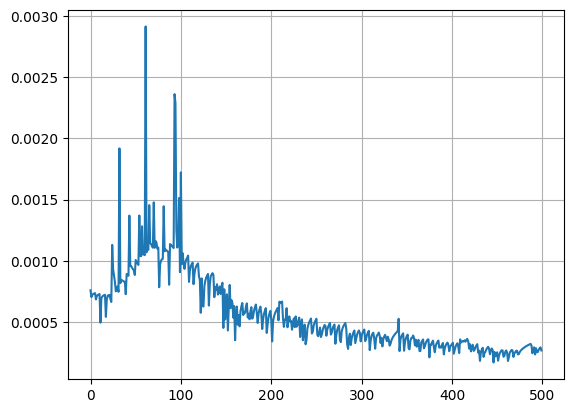

In [23]:
plt.plot(df.iloc[12, 3])
plt.grid()

,user,item,score,prob
0,451.0,1.0,"[-10.428577423095703, -10.428499221801758, -10...","[6.448970816563815e-05, 5.980405330774374e-05,..."
1,451.0,2.0,"[-11.071526527404785, -11.071496963500977, -11...","[3.3904798328876495e-05, 3.14398312184494e-05,..."
2,451.0,3.0,"[-11.23610782623291, -11.235844612121582, -11....","[2.8759703127434477e-05, 2.6675033950596116e-0..."
3,451.0,4.0,"[-10.879405975341797, -10.87905502319336, -10....","[4.1086397686740384e-05, 3.811156057054177e-05..."
4,451.0,5.0,"[-7.152665615081787, -6.918713092803955, -6.99...","[0.0017068714369088411, 0.0019999141804873943,..."
...,...,...,...,...
3022,451.0,3023.0,"[-11.135736465454102, -11.12123966217041, -11....","[3.1796193070476875e-05, 2.9914190236013383e-0..."
3023,451.0,3024.0,"[-14.05190658569336, -14.051877975463867, -14....","[1.7214654235431226e-06, 1.5963091755111236e-0..."
3024,451.0,3025.0,"[-11.475584030151367, -11.475556373596191, -11...","[2.2635036657447927e-05, 2.098937147820834e-05..."
3025,451.0,3026.0,"[-11.089001655578613, -11.087879180908203, -11...","[3.331745392642915e-05, 3.092897168244235e-05,..."
